# 複合スコア comp_ew × ens_lgbm_dnn の評価

`01_compare_candidates` で、AI モデル（`ens_lgbm_dnn`）は IC が高い一方、ロングオンリーの Q1 超過と税後では合成スコア
`comp_ew` に届かないことが分かった。両者の情報の違いを取り込むため、`scripts/build_blend.py` で
`comp_ew` : `ens_lgbm_dnn` = 50:50 〜 90:10 の複合スコア（`alpha/blend/comp_ew_{w}_ai_{100−w}`）を作り、親 2 本と比較する。

合成手順: 各月ユニバース内で両スコアを Blom 正規スコアに変換 → `w·z_comp + (1−w)·z_ai` → 再 Blom 化。
評価条件は `01` と同じ（Q1 = 最上位 20%、等ウェイト、対 MSCI India、バッファ 0 / 0.1 / 0.2、税は信託扱い・INR 建て、コスト 15/25bp、バーンイン 12 か月）。

In [1]:
import matplotlib.pyplot as plt
import japanize_matplotlib  # noqa: F401  日本語ラベル用
import numpy as np
import pandas as pd

from alphaeval import InputStore, evaluate_alpha, india_tax_schedule, performance_summary, portfolio_returns, quantile_analysis, weight_portfolio

pd.set_option("display.width", 240)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"axes.grid": True, "grid.alpha": 0.3})

INPUT_ROOT = "../../input/msci_india_imi"
WEIGHTS = [100, 90, 80, 70, 60, 50, 0]   # comp_ew の重み（100 = comp_ew 単体、0 = AI 単体）
SCORES = {"comp_ew (100:0)": "composite/comp_ew", **{f"comp_ew_{w}_ai_{100 - w}": f"blend/comp_ew_{w}_ai_{100 - w}" for w in WEIGHTS[1:-1]}, "ens_lgbm_dnn (0:100)": "my_ai/ens_lgbm_dnn"}
BENCHMARK = "msci_india"
RISK_MODEL, RETURN_COL = "GEMLT", "rtn"
START, END = 201212, 202606
N_QUANTILES = 5
BUFFERS = (0.0, 0.1, 0.2)
COST_BUY, COST_SELL = 0.0015, 0.0025
FPI_TYPE = "trust"
BURN_IN = 12
IC_HORIZONS = (1, 3, 6, 12)
SPLIT = "2019-01-01"   # 参考: 合成スコアの IS/OOS 境界

store = InputStore(INPUT_ROOT)

## 1. 一括評価

In [2]:
univ = store.universe(START, END)
bm = store.benchmark(BENCHMARK, START, END)
rtn = store.returns(RISK_MODEL, RETURN_COL, START, 202607)
schedule = india_tax_schedule(FPI_TYPE)
scores = {k: store.alpha(v, START, END) for k, v in SCORES.items()}
bm_ret = portfolio_returns(bm, rtn)

results = {}
for name, score in scores.items():
    results[name] = evaluate_alpha(
        score, univ, rtn, bm, n_quantiles=N_QUANTILES, buffers=BUFFERS, scheme="equal",
        ic_horizons=IC_HORIZONS, tax_schedule=schedule, tax_quantiles=(1,),
        cost_buy=COST_BUY, cost_sell=COST_SELL, burn_in=BURN_IN,
    )
    print(f"{name:22s} done")

# 親スコア同士の相関（Blom 化後、月次クロスセクションの Spearman）
a, b = scores["comp_ew (100:0)"], scores["ens_lgbm_dnn (0:100)"]
cols = a.columns.intersection(b.columns); idx = a.index.intersection(b.index)
corr = pd.Series({d: a.loc[d, cols].rank().corr(b.loc[d, cols].rank()) for d in idx})
print(f"comp_ew と ens_lgbm_dnn の順位相関: 平均 {corr.mean():.3f}（最小 {corr.min():.3f}、最大 {corr.max():.3f}）")

comp_ew (100:0)        done


comp_ew_90_ai_10       done


comp_ew_80_ai_20       done


comp_ew_70_ai_30       done


comp_ew_60_ai_40       done


comp_ew_50_ai_50       done


ens_lgbm_dnn (0:100)   done
comp_ew と ens_lgbm_dnn の順位相関: 平均 0.540（最小 0.293、最大 0.733）


## 2. IC

In [3]:
rows = {}
for name, r in results.items():
    s = r.ic_summary
    rows[name] = {"IC 1m": s.loc["mean", "1"], "ICIR 1m": s.loc["icir", "1"], "t 1m": s.loc["t_stat", "1"], "勝率 1m": s.loc["hit_rate", "1"], "IC 3m": s.loc["mean", "3"], "IC 6m": s.loc["mean", "6"], "IC 12m": s.loc["mean", "12"]}
ic_tbl = pd.DataFrame(rows).T
display(ic_tbl.round(3))

,IC 1m,ICIR 1m,t 1m,勝率 1m,IC 3m,IC 6m,IC 12m
comp_ew (100:0),0.056,0.490,6.253,0.656,0.083,0.092,0.074
comp_ew_90_ai_10,0.061,0.513,6.548,0.669,0.088,0.096,0.075
comp_ew_80_ai_20,0.066,0.533,6.802,0.675,0.092,0.100,0.076
comp_ew_70_ai_30,0.070,0.548,7.001,0.675,0.096,0.103,0.077
comp_ew_60_ai_40,0.074,0.559,7.140,0.687,0.099,0.106,0.076
comp_ew_50_ai_50,0.077,0.567,7.242,0.687,0.101,0.107,0.075
ens_lgbm_dnn (0:100),0.078,0.551,7.038,0.718,0.093,0.095,0.056


## 3. Q1（等ウェイト）の超過リターンと分位の単調性

In [4]:
def ew_reference(score: pd.DataFrame) -> pd.Series:
    return portfolio_returns(weight_portfolio(score.where(univ.notna()).notna()), rtn)


rows, mono = {}, {}
for name, r in results.items():
    q = r.quantiles[0.0]
    ret = q.returns.iloc[BURN_IN:]
    ref = ew_reference(scores[name]).reindex(ret.index)
    s_bm = performance_summary(ret["Q1"], bm_ret.reindex(ret.index), q.turnover["Q1"].reindex(ret.index))
    s_ew = performance_summary(ret["Q1"], ref)
    s_sp = performance_summary(ret["spread"])
    post = ret.loc[SPLIT:]
    s_post = performance_summary(post["Q1"], bm_ret.reindex(post.index))
    rows[name] = {
        "Q1 超過(vs BM)": s_bm["active_return"], "TE": s_bm["tracking_error"], "IR": s_bm["information_ratio"], "最大DD(超過)": None,
        "Q1 超過(vs EW)": s_ew["active_return"], "IR(vs EW)": s_ew["information_ratio"], "Q1−Q5": s_sp["ann_return"], "年率回転率": s_bm["turnover_annual"],
        f"超過 {SPLIT[:4]}〜": s_post["active_return"], f"IR {SPLIT[:4]}〜": s_post["information_ratio"],
    }
    ex = ret["Q1"] - bm_ret.reindex(ret.index)
    rows[name]["最大DD(超過)"] = float(((1 + ex).cumprod() / (1 + ex).cumprod().cummax() - 1).min())
    mono[name] = {lab: performance_summary(ret[lab])["ann_return"] for lab in q.labels}
q_tbl = pd.DataFrame(rows).T.astype(float)
display(q_tbl.round(3))
print("分位別の年率リターン（Q1 = 最上位）")
display(pd.DataFrame(mono).T.round(3))

,Q1 超過(vs BM),TE,IR,最大DD(超過),Q1 超過(vs EW),IR(vs EW),Q1−Q5,年率回転率,超過 2019〜,IR 2019〜
comp_ew (100:0),0.132,0.114,1.157,-0.174,0.092,1.546,0.177,4.049,0.127,1.005
comp_ew_90_ai_10,0.132,0.111,1.192,-0.157,0.092,1.513,0.185,4.093,0.127,1.048
comp_ew_80_ai_20,0.131,0.106,1.234,-0.142,0.091,1.472,0.184,4.159,0.125,1.091
comp_ew_70_ai_30,0.134,0.101,1.321,-0.142,0.094,1.487,0.191,4.218,0.127,1.160
comp_ew_60_ai_40,0.135,0.097,1.385,-0.133,0.095,1.425,0.201,4.391,0.125,1.187
comp_ew_50_ai_50,0.134,0.094,1.415,-0.134,0.093,1.354,0.202,4.540,0.118,1.179
ens_lgbm_dnn (0:100),0.109,0.085,1.288,-0.141,0.069,0.916,0.161,5.165,0.095,1.141


分位別の年率リターン（Q1 = 最上位）


,Q1,Q2,Q3,Q4,Q5
comp_ew (100:0),0.271,0.193,0.153,0.122,0.055
comp_ew_90_ai_10,0.272,0.201,0.148,0.126,0.048
comp_ew_80_ai_20,0.272,0.216,0.136,0.125,0.047
comp_ew_70_ai_30,0.277,0.208,0.148,0.122,0.041
comp_ew_60_ai_40,0.278,0.208,0.157,0.121,0.032
comp_ew_50_ai_50,0.278,0.202,0.166,0.122,0.028
ens_lgbm_dnn (0:100),0.248,0.200,0.172,0.134,0.037


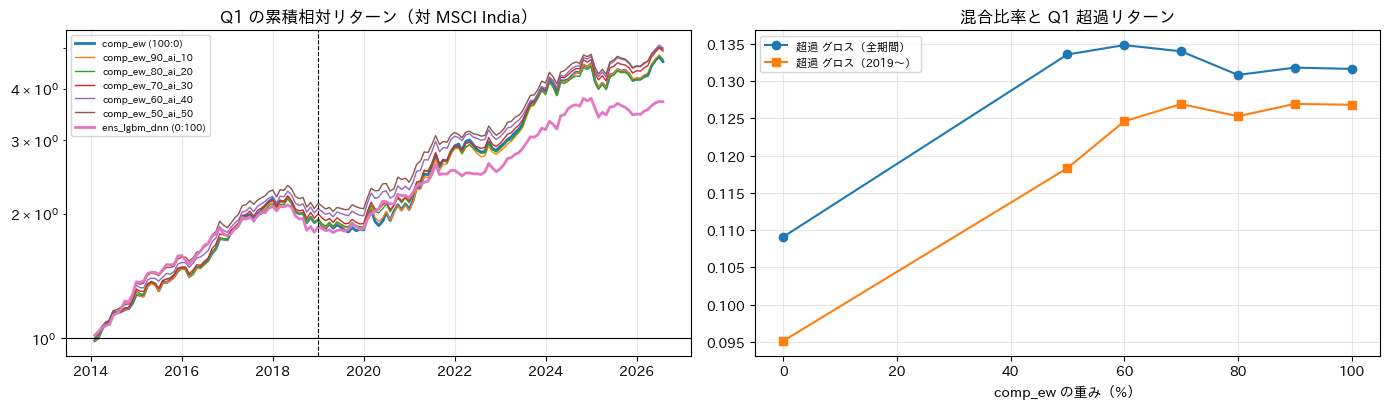

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
for name in results:
    q1 = results[name].quantiles[0.0].returns["Q1"].iloc[BURN_IN:]
    axes[0].plot(q1.index, (1 + q1).cumprod() / (1 + bm_ret.reindex(q1.index)).cumprod(), label=name, linewidth=2 if name.endswith(")") else 1)
axes[0].axhline(1, color="k", linewidth=0.8)
axes[0].axvline(pd.Timestamp(SPLIT), color="k", linestyle="--", linewidth=0.8)
axes[0].set_yscale("log")
axes[0].set_title("Q1 の累積相対リターン（対 MSCI India）")
axes[0].legend(fontsize=7)
w_axis = WEIGHTS
axes[1].plot(w_axis, q_tbl["Q1 超過(vs BM)"].to_numpy(), marker="o", label="超過 グロス（全期間）")
axes[1].plot(w_axis, q_tbl[f"超過 {SPLIT[:4]}〜"].to_numpy(), marker="s", label=f"超過 グロス（{SPLIT[:4]}〜）")
axes[1].set_xlabel("comp_ew の重み（%）")
axes[1].set_title("混合比率と Q1 超過リターン")
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

## 4. 時価総額ウェイト版（キャパシティ）

In [6]:
rows = {}
for name, score in scores.items():
    q = quantile_analysis(score, rtn, univ, n_quantiles=N_QUANTILES, scheme="size", size=univ, max_weight=0.05)
    ret = q.returns["Q1"].iloc[BURN_IN:]
    s = performance_summary(ret, bm_ret.reindex(ret.index), q.turnover["Q1"].reindex(ret.index))
    rows[name] = {"Q1 CW 超過(vs BM)": s["active_return"], "TE": s["tracking_error"], "IR": s["information_ratio"], "年率回転率": s["turnover_annual"]}
cw_tbl = pd.DataFrame(rows).T
display(cw_tbl.round(3))

,Q1 CW 超過(vs BM),TE,IR,年率回転率
comp_ew (100:0),0.096,0.089,1.082,4.167
comp_ew_90_ai_10,0.096,0.086,1.118,4.185
comp_ew_80_ai_20,0.086,0.082,1.059,4.209
comp_ew_70_ai_30,0.090,0.079,1.133,4.234
comp_ew_60_ai_40,0.090,0.077,1.175,4.402
comp_ew_50_ai_50,0.083,0.076,1.096,4.519
ens_lgbm_dnn (0:100),0.054,0.066,0.821,5.057


## 5. バッファと税控除後（Q1、等ウェイト）

年率回転率  超過 グロス  コストドラッグ  税ドラッグ   短期比率  超過 税後  IR 税後     TE
スコア                  バッファ                                                           
comp_ew (100:0)      0.0   4.049   0.132    0.018  0.041  0.786  0.082  0.766  0.114
                     0.1   2.738   0.123    0.012  0.035  0.659  0.085  0.812  0.109
                     0.2   2.076   0.113    0.009  0.030  0.581  0.081  0.792  0.106
comp_ew_90_ai_10     0.0   4.093   0.132    0.019  0.042  0.804  0.082  0.787  0.111
                     0.1   2.777   0.122    0.012  0.035  0.672  0.083  0.813  0.106
                     0.2   2.082   0.114    0.010  0.030  0.574  0.081  0.821  0.103
comp_ew_80_ai_20     0.0   4.159   0.131    0.020  0.042  0.815  0.079  0.797  0.106
                     0.1   2.823   0.124    0.013  0.036  0.684  0.084  0.851  0.103
                     0.2   2.101   0.117    0.010  0.032  0.598  0.083  0.854  0.100
comp_ew_70_ai_30     0.0   4.218   0.134    0.020  0.044  0.825  0.080  0.848  0.101
                     0.1   2.868   0.128    0.013  0.038  0.692  0.086  0.909  0.099
                     0.2   2.104   0.117    0.010  0.032  0.600  0.083  0.896  0.096
comp_ew_60_ai_40     0.0   4.391   0.135    0.021  0.045  0.839  0.079  0.872  0.097
                     0.1   2.938   0.127    0.014  0.039  0.719  0.083  0.927  0.094
                     0.2   2.148   0.118    0.011  0.032  0.617  0.082  0.919  0.093
comp_ew_50_ai_50     0.0   4.540   0.134    0.022  0.045  0.857  0.077  0.879  0.094
                     0.1   3.033   0.124    0.015  0.039  0.767  0.080  0.914  0.092
                     0.2   2.200   0.115    0.011  0.033  0.632  0.079  0.925  0.089
ens_lgbm_dnn (0:100) 0.0   5.165   0.109    0.026  0.043  0.933  0.051  0.653  0.085
                     0.1   3.604   0.103    0.019  0.039  0.858  0.055  0.727  0.081
                     0.2   2.587   0.097    0.014  0.034  0.756  0.058  0.759  0.079

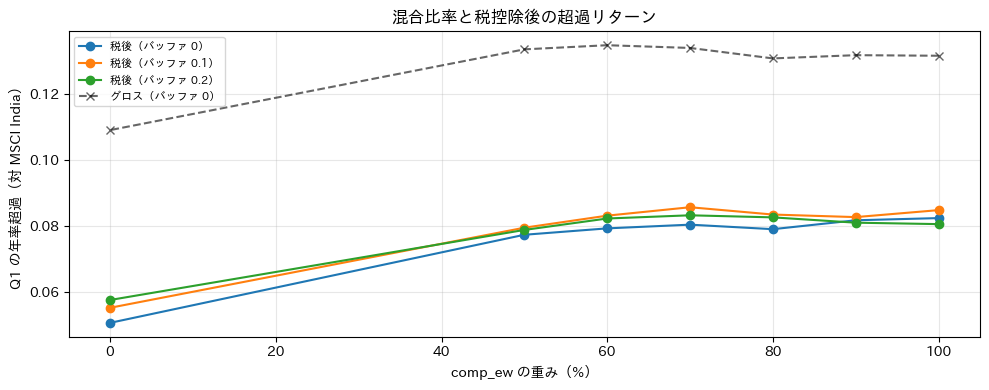

In [7]:
rows = {}
for name, r in results.items():
    for b in BUFFERS:
        s = r.summary[(f"buffer={b:g}", "Q1")]
        rows[(name, b)] = {"年率回転率": s["turnover_annual"], "超過 グロス": s["active_return"], "コストドラッグ": s["cost_drag_annual"], "税ドラッグ": s["tax_drag_annual"], "短期比率": s["short_ratio_mean"], "超過 税後": s["r_net_active_return"], "IR 税後": s["r_net_information_ratio"], "TE": s["tracking_error"]}
tax_tbl = pd.DataFrame(rows).T
tax_tbl.index.names = ["スコア", "バッファ"]
display(tax_tbl.round(3))

fig, ax = plt.subplots(figsize=(10, 4))
for b in BUFFERS:
    ax.plot(WEIGHTS, [tax_tbl.loc[(n, b), "超過 税後"] for n in results], marker="o", label=f"税後（バッファ {b:g}）")
ax.plot(WEIGHTS, [tax_tbl.loc[(n, 0.0), "超過 グロス"] for n in results], marker="x", linestyle="--", color="k", alpha=0.6, label="グロス（バッファ 0）")
ax.set_xlabel("comp_ew の重み（%）")
ax.set_ylabel("Q1 の年率超過（対 MSCI India）")
ax.set_title("混合比率と税控除後の超過リターン")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 6. まとめ表

In [8]:
summary = pd.DataFrame(
    {
        "IC 1m": ic_tbl["IC 1m"], "ICIR": ic_tbl["ICIR 1m"],
        "Q1 超過 グロス": q_tbl["Q1 超過(vs BM)"], "IR": q_tbl["IR"], "対 EW": q_tbl["Q1 超過(vs EW)"], f"超過 {SPLIT[:4]}〜": q_tbl[f"超過 {SPLIT[:4]}〜"],
        "CW 超過": cw_tbl["Q1 CW 超過(vs BM)"], "回転率": q_tbl["年率回転率"],
        "税後超過（b=0）": [tax_tbl.loc[(n, 0.0), "超過 税後"] for n in results],
        "税後超過（b=0.2）": [tax_tbl.loc[(n, 0.2), "超過 税後"] for n in results],
        "税後 IR（b=0.2）": [tax_tbl.loc[(n, 0.2), "IR 税後"] for n in results],
    }
)
display(summary.round(3))

,IC 1m,ICIR,Q1 超過 グロス,IR,対 EW,超過 2019〜,CW 超過,回転率,税後超過（b=0）,税後超過（b=0.2）,税後 IR（b=0.2）
comp_ew (100:0),0.056,0.490,0.132,1.157,0.092,0.127,0.096,4.049,0.082,0.081,0.792
comp_ew_90_ai_10,0.061,0.513,0.132,1.192,0.092,0.127,0.096,4.093,0.082,0.081,0.821
comp_ew_80_ai_20,0.066,0.533,0.131,1.234,0.091,0.125,0.086,4.159,0.079,0.083,0.854
comp_ew_70_ai_30,0.070,0.548,0.134,1.321,0.094,0.127,0.090,4.218,0.080,0.083,0.896
comp_ew_60_ai_40,0.074,0.559,0.135,1.385,0.095,0.125,0.090,4.391,0.079,0.082,0.919
comp_ew_50_ai_50,0.077,0.567,0.134,1.415,0.093,0.118,0.083,4.540,0.077,0.079,0.925
ens_lgbm_dnn (0:100),0.078,0.551,0.109,1.288,0.069,0.095,0.054,5.165,0.051,0.058,0.759


## 7. 所見

**親スコアの関係**: `comp_ew` と `ens_lgbm_dnn` の月次順位相関は平均 0.54（0.29〜0.73）。重なりは半分程度で、合成による分散効果の余地がある。

**混合比率ごとの結果（Q1、等ウェイト、対 MSCI India）**

| comp:ai | IC | Q1 超過 グロス | TE | IR | 最大 DD（超過） | 回転率 | 税後超過（b=0.2） | 税後 IR（b=0.2） |
| --- | --- | --- | --- | --- | --- | --- | --- | --- |
| 100:0 | 0.056 | 13.2% | 11.4% | 1.16 | −17.4% | 405% | 8.1% | 0.79 |
| 90:10 | 0.061 | 13.2% | 11.1% | 1.19 | −15.7% | 409% | 8.1% | 0.82 |
| 80:20 | 0.066 | 13.1% | 10.6% | 1.23 | −14.2% | 416% | 8.3% | 0.85 |
| 70:30 | 0.070 | 13.4% | 10.1% | 1.32 | −14.2% | 422% | 8.3% | 0.90 |
| **60:40** | 0.074 | **13.5%** | 9.7% | **1.39** | **−13.3%** | 439% | 8.2% | 0.92 |
| 50:50 | 0.077 | 13.4% | 9.4% | 1.42 | −13.4% | 454% | 7.9% | 0.93 |
| 0:100 | 0.078 | 10.9% | 8.5% | 1.29 | −14.1% | 517% | 5.8% | 0.76 |

- **超過リターンは AI の比率を上げてもほぼ変わらない**（13.1〜13.5%）。一方 **TE は単調に低下**（11.4% → 9.4%）し、
  IR は 1.16 → 1.42 へ改善。最大ドローダウンも −17% → −13% に縮む。AI スコアの寄与はリターンの上積みではなく
  **リスクの低減（分散効果）** として現れている。
- IC は比率にほぼ比例して上がり、3〜12 か月 IC は混合の方が親のどちらよりも高い（6 か月 IC: 0.092 / 0.095 → 0.107）。
- Q5（最下位）のリターンは AI 比率とともに下がる（5.5% → 2.8%）。Q1−Q5 スプレッドの改善（17.7% → 20.2%）は下位側から来ている。
- 回転率は AI 比率とともに上昇（405% → 454%）し、税後の超過は 8% 前後で横ばい。税後 IR は TE 低下により 0.79 → 0.93 に改善。
- 2019 年以降（合成スコアの OOS 期間）でも超過 11.8〜12.7% で、混合によって劣化はしない。50:50 のみやや低い（11.8%）。
- 時価総額ウェイトでは 80:20〜60:40 で 8.6〜9.0%（comp 9.6%）。AI 比率が高いほど小型依存がやや増える。

**判断**

1. 採用候補は **60:40（`comp_ew_60_ai_40`）**。グロスの超過が最大、IR 1.39、最大 DD 最小で、50:50 との差は IR で僅差、
   2019 年以降の超過と CW の減衰では 60:40 が優位。
2. 70:30 は保守的な代替（TE 10.1%、2019 年以降 12.7%、CW 9.0%）。AI モデルの運用実績が浅い段階ではこちらから始め、
   実績が積み上がれば 60:40 へ寄せる運用も考えられる。
3. 税後の超過は比率によらず 8% 前後で、混合の便益は税後 IR（0.79 → 0.92）に出る。回転率は AI 比率とともに上がるので、
   平滑化版（`ens_lgbm_dnn_hl1`）を混ぜる案も試す価値がある（`01` で hl1 の税後が単体で優位だった）。

**次のステップ候補**

- `comp_ew` × `ens_lgbm_dnn_hl1` の混合（回転率を抑えつつ IR 改善を狙う）
- 60:40 を bax の最適化に入力し、制約下（TE 5%、業種 ±3%、個別 ±3%）での実現超過・回転率・税後を `alphaeval.bax` で確認する